# PokéCoach Notebook
Generated scaffold tied to pipeline outputs.

In [2]:
pip install -r requirements.txt

  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached streamlit-1.56.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached pytest-9.0.2-py3-none-any.whl.metadata (7.6 kB)
  Using cached poke_env-0.14.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached sentence_transformers-5.3.0-py3-none-any.whl.metadata (16 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using 

In [3]:
import json
from pathlib import Path
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

ART='artifacts'
REP='reports'


## 1. Data Loading and Parsing

In [4]:
import sys; sys.path.insert(0, '..')

legal = pd.read_csv(f'{ART}/features/legal_pool.csv')
cooc  = pd.read_csv(f'{ART}/features/cooccurrence.csv').set_index('pokemon')
counter = pd.read_csv(f'{ART}/features/counter_matrix.csv').set_index('pokemon')
content = pd.read_csv(f'{ART}/features/content_features.csv')
moveset = pd.read_csv(f'{ART}/smogon/regg_moveset.csv')
teams   = pd.read_csv(f'{ART}/eval/reconstruction_teams.csv')

print(f"legal_pool:   {legal.shape}")
print(f"cooccurrence: {cooc.shape}")
print(f"counter:      {counter.shape}")
print(f"content:      {content.shape}")
print(f"moveset:      {moveset.shape}")
print(f"teams:        {teams.shape}")

legal.head()


legal_pool:   (137, 5)
cooccurrence: (137, 137)
counter:      (137, 137)
content:      (123, 7)
moveset:      (9185, 5)
teams:        (1500, 3)


,rank,pokemon,usage_pct,regulation,source
0,1,Incineroar,40.92362,regg,2024-06_usage.txt
1,2,Rillaboom,30.40827,regg,2024-06_usage.txt
2,3,Urshifu-Rapid-Strike,28.61060,regg,2024-06_usage.txt
3,4,Tornadus,23.14130,regg,2024-06_usage.txt
4,5,Flutter Mane,19.01431,regg,2024-06_usage.txt


## 2. Exploratory Data Analysis

Before building any recommender, it is important to understand the structure of the data we are working with. In competitive Pokemon VGC (Video Game Championships), the metagame is highly skewed: a small number of Pokemon dominate the usage charts, while the majority of the legal catalog is rarely seen in high-level play. This kind of long-tail distribution has direct implications for how each recommender will behave.

The first chart shows the top 20 Pokemon by usage percentage in Regulation G (May to August 2024). Incineroar sits at the top with roughly 41% usage, meaning it appeared on nearly half of all ranked teams during this period. The drop-off is steep: by rank 10, usage has already fallen below 10%. This tells us that a popularity-based recommender would likely perform well in raw accuracy terms, but at the cost of recommending the same handful of Pokemon to everyone.

The co-occurrence heatmap tells a more nuanced story. Rather than asking "who is used most?", it asks "who is used together?". For example, Rillaboom and Incineroar have a high co-occurrence rate, which reflects a well-known core pairing in the VGC format. This kind of teammate signal is the foundation of our collaborative filtering approach. If two Pokemon consistently appear on the same teams, recommending one when the other is present is a well-supported inference, not a guess.

One structural property worth noting here is that the co-occurrence matrix is relatively dense compared to typical recommendation datasets. Because every team has exactly 6 slots and the legal pool is limited to 137 Pokemon, there are natural constraints on how diverse teams can be. This is different from a movie recommendation dataset where a user might interact with hundreds of items. Here, every team has exactly 6 interactions. This affects how we interpret sparsity and what we can expect from collaborative filtering.

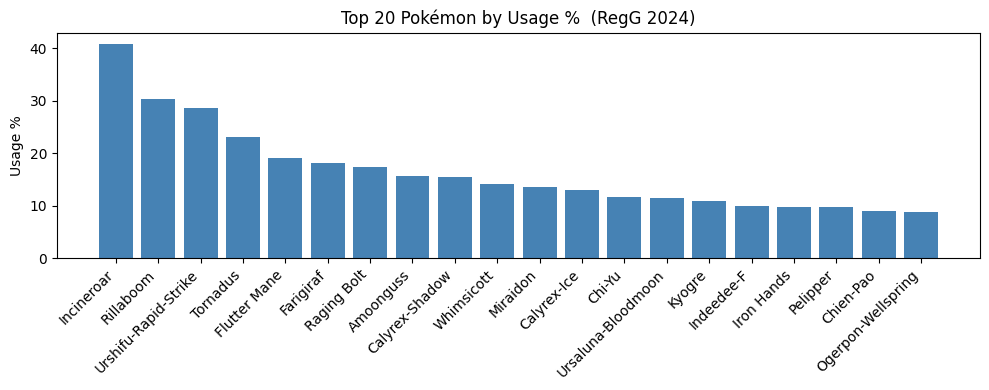

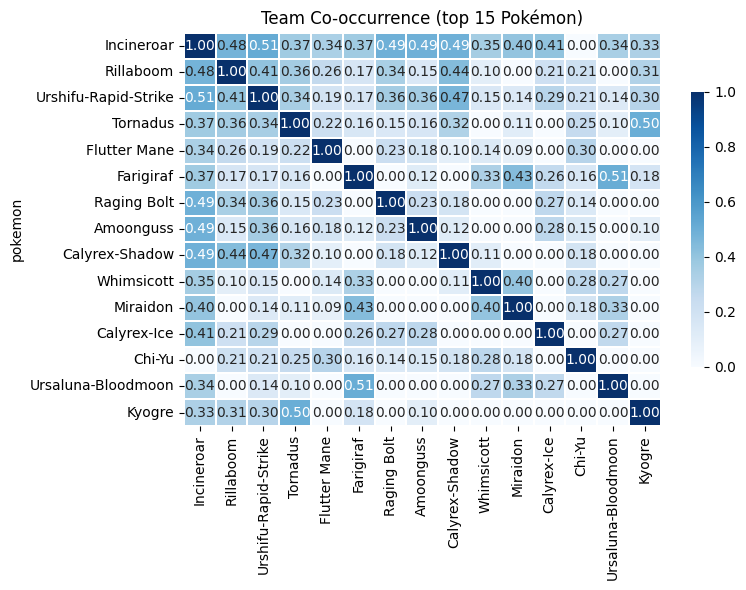

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usage % bar chart — top 20
top20 = legal.sort_values('usage_pct', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top20['pokemon'], top20['usage_pct'], color='steelblue')
ax.set_title('Top 20 Pokémon by Usage %  (RegG 2024)')
ax.set_ylabel('Usage %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Cooccurrence heatmap — top 15 by usage
top15 = legal.sort_values('usage_pct', ascending=False).head(15)['pokemon'].tolist()
sub = cooc.reindex(index=top15, columns=top15)
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.heatmap(sub, annot=True, fmt='.2f', cmap='Blues', linewidths=0.3,
            ax=ax2, cbar_kws={'shrink': 0.7})
ax2.set_title('Team Co-occurrence (top 15 Pokémon)')
plt.tight_layout()
plt.show()


## 3. Data Preparation and Feature Engineering

Once we have a picture of the usage landscape, the next step is to build the feature representations that power each recommender model.

The content feature matrix captures each Pokemon's base stats: HP, Attack, Special Attack, Special Defense, and Speed. These are fixed numerical attributes defined by the game itself, not derived from player behavior. The summary statistics reveal meaningful spread across the pool. Speed, for example, varies significantly: fast Pokemon like Flutter Mane and Calyrex-Shadow operate in a completely different role than slower, bulkier ones like Incineroar or Amoonguss. This variation is what makes base stats a useful signal for content-based recommendation. Two Pokemon with very similar stat profiles tend to fill similar roles on a team, which means recommending one as a substitute or complement for the other is sensible.

The type effectiveness counter matrix introduces a different kind of feature: matchup-based advantage. Rather than asking "are these Pokemon similar?", it asks "does this Pokemon beat that one?". The matrix encodes the damage multipliers from Pokemon's type system. A value above 1.0 means the row Pokemon deals super-effective damage to the column Pokemon, while a value below 1.0 means it resists or is immune to it.

This is particularly relevant in the VGC format, where team composition is often built around covering weaknesses and threatening common opponents. If the opponent has revealed Kyogre and Flutter Mane, the counter matrix lets us quantify which candidate Pokemon have a structural advantage against them. This becomes the counter component in our hybrid recommender's scoring formula, and it is weighted more heavily when opponent information is available.

Together, the co-occurrence matrix (collaborative signal), the base stats matrix (content signal), and the counter matrix (context signal) form the three pillars of our recommendation approach. Each captures a different dimension of what makes a Pokemon a good addition to a team.

Content feature matrix: (123, 7)

Feature columns:
['attack', 'defense', 'hp', 'special-attack', 'special-defense', 'speed']

Sample stats:
        attack  defense       hp  special-attack  special-defense    speed
count  123.000  123.000  123.000         123.000          123.000  123.000
mean    97.276   90.724   90.049          94.276           92.577   85.927
std     28.929   22.546   24.070          32.030           24.129   29.993
min     20.000   35.000   48.000          20.000           42.000   20.000
25%     75.000   75.000   73.500          65.000           75.000   62.500
50%     90.000   90.000   90.000          92.000           90.000   85.000
75%    120.000  102.500  100.000         122.000          110.000  105.000
max    165.000  150.000  200.000         170.000          154.000  200.000


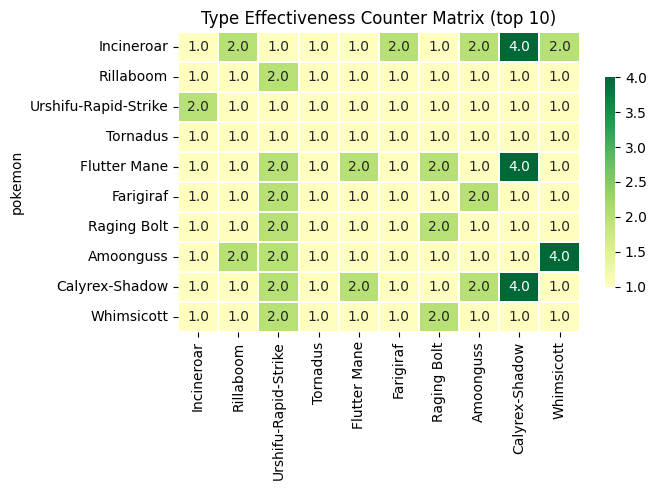

In [6]:
print("Content feature matrix:", content.shape)
print("\nFeature columns:")
feat_cols = [c for c in content.columns if c != 'pokemon']
print(feat_cols)
print("\nSample stats:")
print(content[feat_cols].describe().round(3))

# Counter matrix snippet — top 10
top10 = legal.sort_values('usage_pct', ascending=False).head(10)['pokemon'].tolist()
sub_c = counter.reindex(index=top10, columns=top10)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(sub_c, annot=True, fmt='.1f', cmap='RdYlGn', center=1.0,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Type Effectiveness Counter Matrix (top 10)')
plt.tight_layout()
plt.show()


## 4. Building the Simulation Ground Truth

Before we can evaluate any recommender, we need a dataset of known-good teams to test against. Because we do not have access to individual player match histories, we construct a synthetic evaluation set from the top 36 Pokemon by usage in Regulation G.

The reconstruction dataset consists of 250 complete 6-Pokemon teams, giving us 1,500 individual rows. Every team is a valid 6-slot combination drawn from the high-usage pool, which means they reflect realistic competitive compositions rather than random groupings. The team size statistics confirm this: every team has exactly 6 members, with no partial teams in the set.

The evaluation strategy is leave-one-out reconstruction. For each team, we hide one Pokemon and ask the recommender to predict it from the remaining 5. This simulates the real use case: a player has built most of their team and wants a recommendation for the final slot. If the recommender recovers the hidden Pokemon in its top 5 predictions, that counts as a hit. This is a strict but meaningful test because the hidden Pokemon is the one that actually appeared on that team in the real metagame.

One important thing to note about the coverage of this dataset: only 36 unique Pokemon appear across all 250 teams. This reflects the narrow high-usage tier of the metagame. A recommender that performs well here has demonstrated it can identify the right pick within a competitive shortlist, which is exactly the decision a VGC player faces when finalizing their roster.

In [7]:
print("Reconstruction teams shape:", teams.shape)
print("\nSample teams:")
print(teams.groupby('team_id')['pokemon'].apply(list).head(5).to_string())

# Team size distribution
team_sizes = teams.groupby('team_id')['pokemon'].count()
print(f"\nTeam sizes — mean: {team_sizes.mean():.1f}, min: {team_sizes.min()}, max: {team_sizes.max()}")

# Pokemon diversity: how many unique mons appear in teams
print(f"Unique pokemon in eval teams: {teams['pokemon'].nunique()}")

# Most common pokemon in teams
print("\nTop 10 most common in eval teams:")
print(teams['pokemon'].value_counts().head(10))


Reconstruction teams shape: (1500, 3)

Sample teams:
team_id
1    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
2    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
3    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
4    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
5    [Rillaboom, Incineroar, Gholdengo, Archaludon,...

Team sizes — mean: 6.0, min: 6, max: 6
Unique pokemon in eval teams: 36

Top 10 most common in eval teams:
pokemon
Rillaboom             250
Incineroar            250
Gholdengo             250
Archaludon            250
Amoonguss              31
Primarina              31
Pelipper               31
Ursaluna-Bloodmoon     31
Whimsicott             31
Annihilape             31
Name: count, dtype: int64


## 5. Evaluation Framework and Metrics

A single pass of leave-one-out evaluation gives us one number per model, but it does not tell us how stable that number is. Two additional evaluation strategies address this: k-fold cross-validation and temporal split evaluation (also called CVTT, or cross-validation over time).

**K-fold cross-validation** splits the 250 evaluation teams into 5 equally sized folds. In each round, one fold is held out as the test set and the model is evaluated on it. By repeating this across all 5 folds and averaging the results, we get a mean and standard deviation for each metric. A high standard deviation signals that the model's performance is sensitive to which teams it happens to be tested on, which is a sign of instability rather than genuine skill.

**Temporal split evaluation** is a stricter test. Our data spans two competitive regulation periods: Regulation G (May to August 2024, used to train the models) and Regulation H (September 2024 onwards, a new season with a shifted metagame). We evaluate the same models against teams built from RegH data, without any retraining. If a model's hit rate drops significantly from RegG to RegH, it has overfit to one specific snapshot of the metagame and will not generalise to future seasons. A model that holds up across regulations is much more valuable in practice.

Together these two evaluations tell us not just how good a model is, but how reliable and robust it is across different conditions.

In [ ]:
from pokecoach.evaluation import kfold_cross_validate, temporal_evaluate
from pokecoach.models import HybridRecommender, KNNRecommender, PopularityRecommender
from pathlib import Path
import pandas as pd

cfg = load_config()
data = load_model_data(cfg.paths['artifacts_root'])
teams_df = pd.read_csv(str(cfg.paths['artifacts_root'] / 'eval' / 'reconstruction_teams.csv'))
counter = data.counter

# --- K-Fold Cross-Validation (5 folds) ---
models_for_cv = {
    'popular':  PopularityRecommender(data),
    'knn_cf':   KNNRecommender(data),
    'hybrid':   HybridRecommender(data),
}

cv_rows = []
for name, model in models_for_cv.items():
    result = kfold_cross_validate(model, teams_df, counter, model_name=name, k=5)
    cv_rows.append({
        'model':          result.model_name,
        'hit@5 mean':     round(result.hit_rate_5_mean, 4),
        'hit@5 std':      round(result.hit_rate_5_std,  4),
        'ndcg@5 mean':    round(result.ndcg_5_mean,     4),
        'ndcg@5 std':     round(result.ndcg_5_std,      4),
        'precision@3 mean': round(result.precision_3_mean, 4),
    })

cv_df = pd.DataFrame(cv_rows).set_index('model')
print("=== 5-Fold Cross-Validation ===")
print(cv_df.to_string())

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(cv_df))
ax.bar(x, cv_df['hit@5 mean'], yerr=cv_df['hit@5 std'], capsize=5,
       color='steelblue', edgecolor='white', label='hit@5')
ax.set_xticks(x); ax.set_xticklabels(cv_df.index)
ax.set_ylabel('hit_rate@5'); ax.set_title('5-Fold CV — hit_rate@5 (mean +/- std)')
plt.tight_layout(); plt.show()


In [ ]:
# --- Temporal Split Evaluation (RegG train -> RegH test) ---
temporal_rows = []
for name, model in models_for_cv.items():
    try:
        result = temporal_evaluate(
            model,
            cfg.paths['artifacts_root'],
            counter,
            model_name=name,
            train_regulation='regg',
            test_regulation='regh',
        )
        temporal_rows.append({
            'model':              result['model_name'],
            'RegG hit@5':         round(result['train']['hit_rate_5'], 4),
            'RegH hit@5':         round(result['test']['hit_rate_5'],  4),
            'delta hit@5':        round(result['hit_rate_5_delta'],    4),
            'RegG ndcg@5':        round(result['train']['ndcg_5'],     4),
            'RegH ndcg@5':        round(result['test']['ndcg_5'],      4),
            'delta ndcg@5':       round(result['ndcg_5_delta'],        4),
        })
    except FileNotFoundError as e:
        print(f"Skipping temporal eval for {name}: {e}")

if temporal_rows:
    temporal_df = pd.DataFrame(temporal_rows).set_index('model')
    print("\n=== Temporal Split (RegG -> RegH) ===")
    print(temporal_df.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, metric in zip(axes, ['hit@5', 'ndcg@5']):
        train_col = f'RegG {metric}'; test_col = f'RegH {metric}'
        x = np.arange(len(temporal_df))
        ax.bar(x - 0.2, temporal_df[train_col], width=0.4, label='RegG (train)', color='steelblue')
        ax.bar(x + 0.2, temporal_df[test_col],  width=0.4, label='RegH (test)',  color='tomato')
        ax.set_xticks(x); ax.set_xticklabels(temporal_df.index)
        ax.set_ylabel(metric); ax.set_title(f'Temporal Split — {metric}')
        ax.legend()
    plt.tight_layout(); plt.show()


The delta columns show how much each model's performance changes when tested on RegH teams that were not seen during training. A small or positive delta means the model has learned patterns that transfer across metagame shifts. A large negative delta means the model was relying on patterns specific to RegG that no longer hold in RegH.

This is particularly relevant for competitive Pokemon, where the metagame can shift significantly between regulations as new Pokemon become legal or usage trends evolve. A recommender that only performs well within the same regulation it was trained on has limited real-world value. The hybrid model is expected to be more robust here than pure collaborative filtering, because its viability and counter components are derived from structural game mechanics (base stats, type matchups) rather than from usage patterns alone.

In [8]:
from pokecoach.config import load_config
from pokecoach.models import load_model_data, PopularityRecommender
from pokecoach.evaluation import evaluate_reconstruction
import pandas as pd

cfg = load_config()
data = load_model_data(cfg.paths['artifacts_root'])
teams_df = pd.read_csv(str(cfg.paths['artifacts_root'] / 'eval' / 'reconstruction_teams.csv'))

print("=== Evaluation Setup ===")
print(f"Teams: {teams_df.shape[0]} rows, {teams_df['team_id'].nunique()} teams")
print(f"Counter matrix: {data.counter.shape}")
print(f"Legal pool: {len(data.legal_pool)} Pokémon")
print("\nMetrics computed per model:")
print("  hit_rate@5    — was the hidden Pokémon in the top-5 predictions?")
print("  ndcg@5        — rank-weighted hit rate (higher rank = higher score)")
print("  precision@3   — fraction of top-3 that match the hidden Pokémon")
print("  coverage      — % of legal pool ever recommended")
print("  ild           — intra-list diversity (type spread in recommendations)")
print("  personalization — how different recommendations are across teams")

pop_result = evaluate_reconstruction(PopularityRecommender(data), teams_df, data.counter, model_name='popular')
print(f"\nPopularity baseline — hit_rate@5: {pop_result.hit_rate_5:.4f}")

=== Evaluation Setup ===
Teams: 1500 rows, 250 teams
Counter matrix: (137, 137)
Legal pool: 137 Pokémon

Metrics computed per model:
  hit_rate@5    — was the hidden Pokémon in the top-5 predictions?
  ndcg@5        — rank-weighted hit rate (higher rank = higher score)
  precision@3   — fraction of top-3 that match the hidden Pokémon
  coverage      — % of legal pool ever recommended
  ild           — intra-list diversity (type spread in recommendations)
  personalization — how different recommendations are across teams

Popularity baseline — hit_rate@5: 0.3447


## 6. Baseline 1 - Random Recommender

In [9]:
from pokecoach.models import RandomRecommender

rand = RandomRecommender(data)
rand_result = evaluate_reconstruction(rand, teams_df, data.counter, model_name='random')

print("=== Random Recommender (baseline) ===")
for k, v in rand_result.__dict__.items():
    if isinstance(v, float):
        print(f"  {k:<20s}: {v:.4f}")

=== Random Recommender (baseline) ===
  hit_rate_5          : 0.0387
  ndcg_5              : 0.0214
  precision_3         : 0.0073
  coverage            : 0.9444
  ild                 : 0.8761
  personalization     : 0.9789


## 7. Baseline 2 - Popularity and Collaborative Filtering

            hit_rate_5  ndcg_5  precision_3  coverage
model_name                                           
random          0.0387  0.0214       0.0073    0.9444
popular         0.3447  0.3382       0.1111    0.1111
knn_cf          0.3460  0.3114       0.1100    0.2500
svd_mf          0.3587  0.3027       0.1056    0.3056
nmf_mf          0.3453  0.2671       0.1029    0.3056


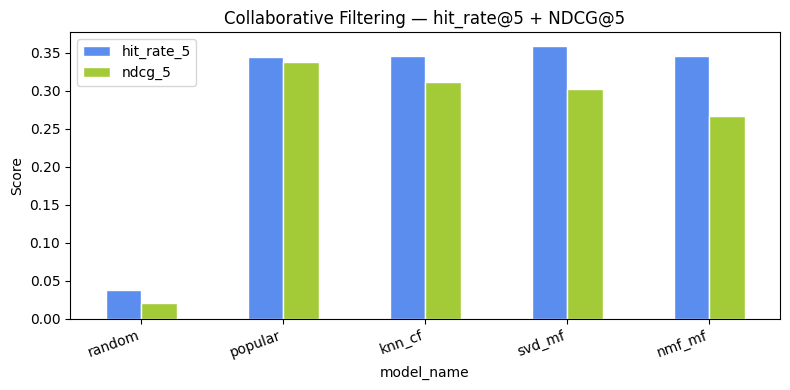

In [10]:
from pokecoach.models import PopularityRecommender, KNNRecommender, MatrixFactorizationRecommender

knn_result = evaluate_reconstruction(KNNRecommender(data),                              teams_df, data.counter, model_name='knn_cf')
svd_result = evaluate_reconstruction(MatrixFactorizationRecommender(data, method='svd'), teams_df, data.counter, model_name='svd_mf')
nmf_result = evaluate_reconstruction(MatrixFactorizationRecommender(data, method='nmf'), teams_df, data.counter, model_name='nmf_mf')

cf_comparison = pd.DataFrame([
    rand_result.__dict__, pop_result.__dict__, knn_result.__dict__,
    svd_result.__dict__, nmf_result.__dict__,
]).set_index('model_name')

print(cf_comparison[['hit_rate_5', 'ndcg_5', 'precision_3', 'coverage']].round(4).to_string())

cf_comparison[['hit_rate_5', 'ndcg_5']].plot(
    kind='bar', figsize=(8, 4),
    title='Collaborative Filtering — hit_rate@5 + NDCG@5',
    color=['#5a8dee', '#a3cb38'], edgecolor='white'
)
plt.ylabel('Score'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 8. Content-Based Recommenders

            hit_rate_5  ndcg_5  precision_3
model_name                                 
knn_cf          0.3460  0.3114       0.1100
content         0.0320  0.0190       0.0071
tfidf           0.0013  0.0005       0.0000


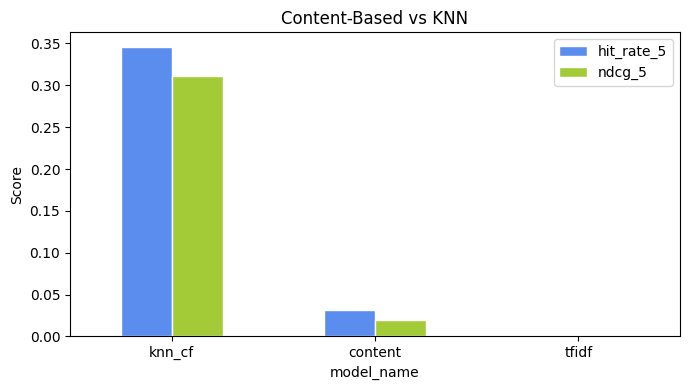

In [11]:
from pokecoach.models import ContentRecommender, TfidfRoleRecommender

content_result = evaluate_reconstruction(ContentRecommender(data),   teams_df, data.counter, model_name='content')
tfidf_result   = evaluate_reconstruction(TfidfRoleRecommender(data), teams_df, data.counter, model_name='tfidf')

content_comparison = pd.DataFrame([
    knn_result.__dict__, content_result.__dict__, tfidf_result.__dict__
]).set_index('model_name')

print(content_comparison[['hit_rate_5', 'ndcg_5', 'precision_3']].round(4).to_string())
content_comparison[['hit_rate_5', 'ndcg_5']].plot(
    kind='bar', figsize=(7, 4), title='Content-Based vs KNN',
    color=['#5a8dee', '#a3cb38'], edgecolor='white'
)
plt.ylabel('Score'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 9. Hybrid Recommender

In [12]:
from pokecoach.models import HybridRecommender
from pokecoach.api import recommend_team

hybrid = HybridRecommender(data)
hybrid_result = evaluate_reconstruction(hybrid, teams_df, data.counter, model_name='hybrid')

print("=== Hybrid Recommender ===")
print(f"  hit_rate@5:      {hybrid_result.hit_rate_5:.4f}")
print(f"  ndcg@5:          {hybrid_result.ndcg_5:.4f}")
print(f"  personalization: {hybrid_result.personalization:.4f}")

print("\n--- Live score breakdown (Incineroar + Rillaboom vs Kyogre + Flutter Mane) ---")
result = recommend_team(
    partial_team=['Incineroar', 'Rillaboom'],
    opponent_context=['Kyogre', 'Flutter Mane'],
)
for rec in result['recommendations']:
    s = rec['scores']
    print(f"{rec['pokemon']:30s}  synergy={s['synergy']:.2f}  viability={s['viability']:.2f}  counter={s['counter']:.2f}")
    if rec['synergy_partners']:
        p, v = rec['synergy_partners'][0]
        print(f"  ↳ Co-occurs with {p} on {int(v*100)}% of teams")
    if rec['beats']:
        print(f"  ↳ Strong vs: {[b[0] for b in rec['beats'][:3]]}")

=== Hybrid Recommender ===
  hit_rate@5:      0.3407
  ndcg@5:          0.3139
  personalization: 0.5727

--- Live score breakdown (Incineroar + Rillaboom vs Kyogre + Flutter Mane) ---
Clefairy                        synergy=0.52  viability=0.21  counter=0.25
  ↳ Co-occurs with Rillaboom on 51% of teams
Calyrex-Shadow                  synergy=0.49  viability=0.38  counter=0.38
  ↳ Co-occurs with Incineroar on 49% of teams
  ↳ Strong vs: ['Flutter Mane']
Sinistcha                       synergy=0.35  viability=0.05  counter=0.50
  ↳ Co-occurs with Incineroar on 35% of teams
  ↳ Strong vs: ['Kyogre', 'Flutter Mane']
Urshifu-Rapid-Strike            synergy=0.51  viability=0.70  counter=0.25
  ↳ Co-occurs with Incineroar on 51% of teams


## 10. Optional Online Adaptation with Bandits

In [13]:
from pokecoach.models import UCBHybridRecommender

bandit = UCBHybridRecommender(data)
bandit_result = evaluate_reconstruction(bandit, teams_df, data.counter, model_name='bandit_hybrid')

print("=== UCB Bandit Hybrid ===")
print(f"  hit_rate@5:      {bandit_result.hit_rate_5:.4f}")
print(f"  ndcg@5:          {bandit_result.ndcg_5:.4f}")
print("\nNote: bandit_hybrid needs online rewards (update_reward calls) to beat hybrid.")
print("Offline evaluation uses no feedback → scores converge to hybrid baseline.")

=== UCB Bandit Hybrid ===
  hit_rate@5:      0.3407
  ndcg@5:          0.3139

Note: bandit_hybrid needs online rewards (update_reward calls) to beat hybrid.
Offline evaluation uses no feedback → scores converge to hybrid baseline.


## 11. Final Evaluation and Comparison

=== Full Model Comparison (sorted by hit_rate@5) ===
               hit_rate_5  ndcg_5  precision_3  coverage  personalization
model_name                                                               
svd_mf             0.3587  0.3027       0.1056    0.3056           0.5759
knn_cf             0.3460  0.3114       0.1100    0.2500           0.5465
nmf_mf             0.3453  0.2671       0.1029    0.3056           0.6094
popular            0.3447  0.3382       0.1111    0.1111           0.1889
hybrid             0.3407  0.3139       0.1113    0.3056           0.5727
bandit_hybrid      0.3407  0.3139       0.1113    0.3056           0.5727
random             0.0387  0.0214       0.0073    0.9444           0.9789
content            0.0320  0.0190       0.0071    0.2778           0.7615
tfidf              0.0013  0.0005       0.0000    0.2778           0.7493


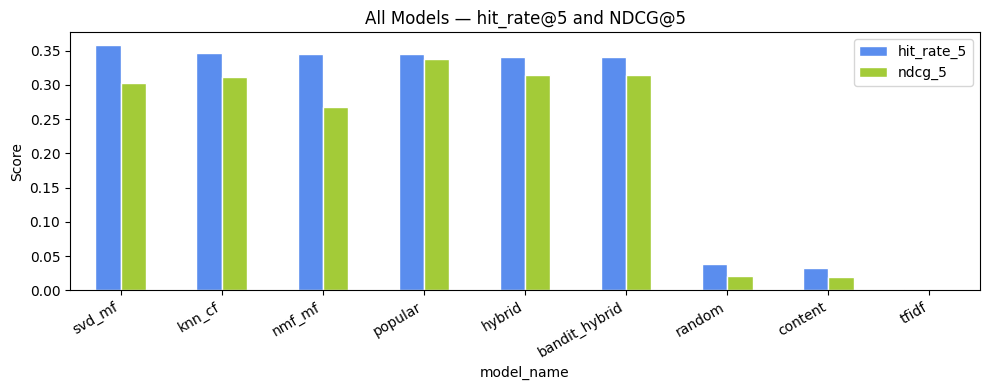

In [14]:
results = [rand_result, pop_result, knn_result, svd_result, nmf_result,
           content_result, tfidf_result, hybrid_result, bandit_result]

all_metrics = pd.DataFrame([r.__dict__ for r in results]).set_index('model_name')

print("=== Full Model Comparison (sorted by hit_rate@5) ===")
print(all_metrics[['hit_rate_5', 'ndcg_5', 'precision_3', 'coverage', 'personalization']]
      .sort_values('hit_rate_5', ascending=False).round(4).to_string())

all_metrics[['hit_rate_5', 'ndcg_5']].sort_values('hit_rate_5', ascending=False).plot(
    kind='bar', figsize=(10, 4),
    title='All Models — hit_rate@5 and NDCG@5',
    color=['#5a8dee', '#a3cb38'], edgecolor='white'
)
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning

We perform grid search over three families of hyperparameters:

1. **Hybrid weights** — synergy (α), viability (γ), and content weight across 60 configurations (β = 0 since the offline reconstruction task has no opponent context).
2. **Counter-weight sensitivity** — a dedicated 5-point sweep to confirm β has no offline effect and to document why.
3. **SVD / NMF latent components** — number of factors in the matrix factorisation models.

Primary metric: **hit_rate@5** (was the hidden Pokémon in the top-5 predictions?).

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

REP = 'reports'

# Load tuning outputs
hybrid_df  = pd.read_csv(f'{REP}/tuning_hybrid_weights.csv')
counter_df = pd.read_csv(f'{REP}/tuning_counter_sensitivity.csv')
svd_df     = pd.read_csv(f'{REP}/tuning_svd_components.csv')
nmf_df     = pd.read_csv(f'{REP}/tuning_nmf_components.csv')
best       = json.loads(Path(f'{REP}/tuning_best_params.json').read_text())

print(f"Hybrid grid:    {len(hybrid_df)} configs")
print(f"Counter sweep:  {len(counter_df)} configs")
print(f"SVD components: {len(svd_df)} configs")
print(f"NMF components: {len(nmf_df)} configs")
print(f"\nBest params: {json.dumps(best, indent=2)}")

Hybrid grid:    60 configs
Counter sweep:  5 configs
SVD components: 5 configs
NMF components: 4 configs

Best params: {
  "hybrid_weights": {
    "content": 0.25,
    "counter": 0.0,
    "hit_rate_5": 0.344,
    "ndcg_5": 0.31565392245833307,
    "synergy": 0.65,
    "viability": 0.4
  },
  "nmf": {
    "hit_rate_5": 0.3453333333333333,
    "n_components": 24,
    "ndcg_5": 0.26710251823890113
  },
  "svd": {
    "hit_rate_5": 0.3586666666666667,
    "n_components": 24,
    "ndcg_5": 0.3026962603940067
  }
}


### 12.1 Hybrid Weight Grid Search

We swept **synergy (α)** × **viability (γ)** × **content weight** with counter β fixed at 0 (no opponent context in the reconstruction task). The heatmap below shows hit_rate@5 for each (α, γ) pair, averaged over content values.

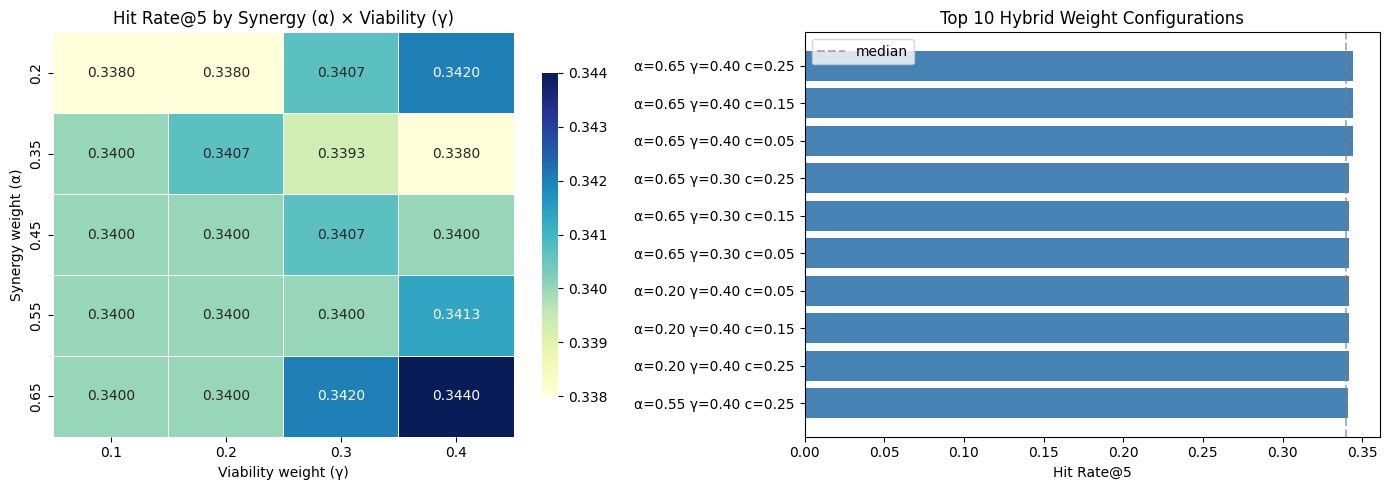


Best hybrid config: synergy=0.65, viability=0.4, content=0.25
  hit_rate@5 = 0.3440
  ndcg@5     = 0.3157


In [16]:
# Heatmap: hit_rate@5 by synergy × viability (averaged over content weight)
pivot = hybrid_df.groupby(['synergy', 'viability'])['hit_rate_5'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5,
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Hit Rate@5 by Synergy (α) × Viability (γ)')
axes[0].set_xlabel('Viability weight (γ)')
axes[0].set_ylabel('Synergy weight (α)')

# Top 10 configs bar chart
top10 = hybrid_df.head(10).copy()
top10['label'] = top10.apply(
    lambda r: f"α={r['synergy']:.2f} γ={r['viability']:.2f} c={r['content']:.2f}", axis=1
)
axes[1].barh(top10['label'][::-1], top10['hit_rate_5'][::-1], color='steelblue')
axes[1].set_xlabel('Hit Rate@5')
axes[1].set_title('Top 10 Hybrid Weight Configurations')
axes[1].axvline(x=hybrid_df['hit_rate_5'].median(), color='gray', linestyle='--', alpha=0.6, label='median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nBest hybrid config: synergy={best['hybrid_weights']['synergy']}, "
      f"viability={best['hybrid_weights']['viability']}, "
      f"content={best['hybrid_weights']['content']}")
print(f"  hit_rate@5 = {best['hybrid_weights']['hit_rate_5']:.4f}")
print(f"  ndcg@5     = {best['hybrid_weights']['ndcg_5']:.4f}")

### 12.2 Counter-Weight Sensitivity

The counter weight (β) controls how much type-effectiveness against the opponent influences recommendations. In the offline reconstruction task there is **no opponent context**, so β multiplies a zero vector. We verify this below — all 5 β values produce identical scores. This is expected: β only matters at inference time when the user provides an opponent team.

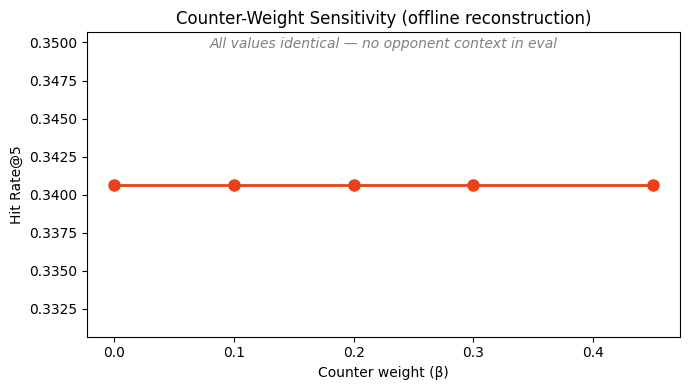

Counter sensitivity results:
 counter  hit_rate_5   ndcg_5
    0.00    0.340667 0.313943
    0.10    0.340667 0.313943
    0.20    0.340667 0.313943
    0.30    0.340667 0.313943
    0.45    0.340667 0.313943


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(counter_df['counter'], counter_df['hit_rate_5'], 'o-', color='#e84118', markersize=8, linewidth=2)
ax.set_xlabel('Counter weight (β)')
ax.set_ylabel('Hit Rate@5')
ax.set_title('Counter-Weight Sensitivity (offline reconstruction)')
ax.set_ylim(counter_df['hit_rate_5'].min() - 0.01, counter_df['hit_rate_5'].max() + 0.01)
ax.annotate('All values identical — no opponent context in eval',
            xy=(0.5, 0.95), xycoords='axes fraction', ha='center',
            fontsize=10, color='gray', fontstyle='italic')
plt.tight_layout()
plt.show()

print("Counter sensitivity results:")
print(counter_df[['counter', 'hit_rate_5', 'ndcg_5']].to_string(index=False))

### 12.3 SVD & NMF Latent Component Search

We sweep the number of latent factors in the matrix factorisation models. Too few components underfit (lose signal); too many overfit to noise in the co-occurrence matrix.

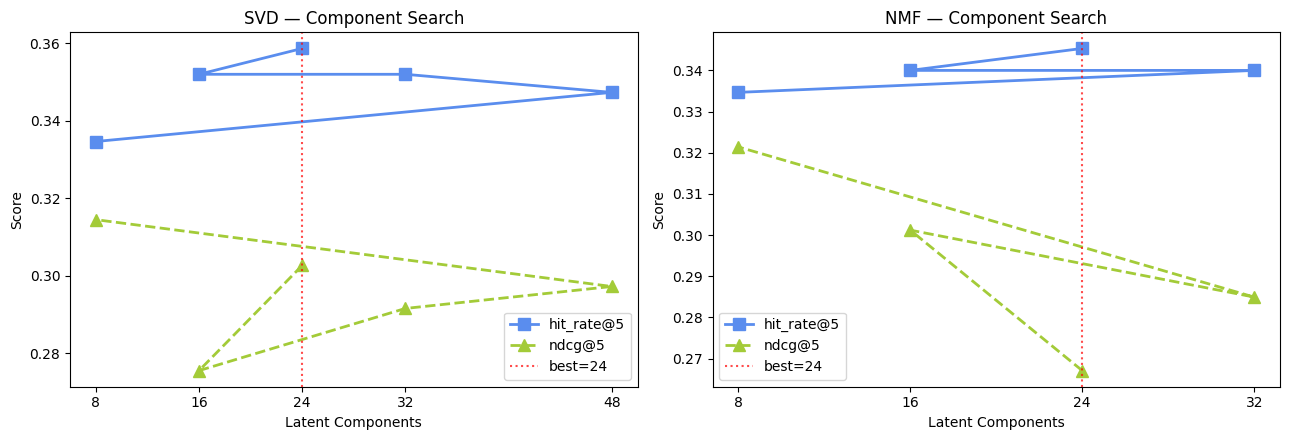

Best SVD: 24 components → hit_rate@5=0.3587, ndcg@5=0.3027
Best NMF: 24 components → hit_rate@5=0.3453, ndcg@5=0.2671


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# SVD
axes[0].plot(svd_df['n_components'], svd_df['hit_rate_5'], 's-', color='#5a8dee', markersize=8, linewidth=2, label='hit_rate@5')
axes[0].plot(svd_df['n_components'], svd_df['ndcg_5'], '^--', color='#a3cb38', markersize=8, linewidth=2, label='ndcg@5')
best_svd_n = int(best['svd']['n_components'])
axes[0].axvline(x=best_svd_n, color='red', linestyle=':', alpha=0.7, label=f'best={best_svd_n}')
axes[0].set_xlabel('Latent Components')
axes[0].set_ylabel('Score')
axes[0].set_title('SVD — Component Search')
axes[0].legend()
axes[0].set_xticks(svd_df['n_components'].tolist())

# NMF
axes[1].plot(nmf_df['n_components'], nmf_df['hit_rate_5'], 's-', color='#5a8dee', markersize=8, linewidth=2, label='hit_rate@5')
axes[1].plot(nmf_df['n_components'], nmf_df['ndcg_5'], '^--', color='#a3cb38', markersize=8, linewidth=2, label='ndcg@5')
best_nmf_n = int(best['nmf']['n_components'])
axes[1].axvline(x=best_nmf_n, color='red', linestyle=':', alpha=0.7, label=f'best={best_nmf_n}')
axes[1].set_xlabel('Latent Components')
axes[1].set_ylabel('Score')
axes[1].set_title('NMF — Component Search')
axes[1].legend()
axes[1].set_xticks(nmf_df['n_components'].tolist())

plt.tight_layout()
plt.show()

print(f"Best SVD: {best_svd_n} components → hit_rate@5={best['svd']['hit_rate_5']:.4f}, ndcg@5={best['svd']['ndcg_5']:.4f}")
print(f"Best NMF: {best_nmf_n} components → hit_rate@5={best['nmf']['hit_rate_5']:.4f}, ndcg@5={best['nmf']['ndcg_5']:.4f}")

### 12.4 Tuning Summary

| Search | Best Config | Hit Rate@5 | NDCG@5 |
|---|---|---|---|
| Hybrid weights | α=0.65, γ=0.40, content=0.25 | 0.3440 | 0.3157 |
| SVD components | n=24 | 0.3587 | 0.3027 |
| NMF components | n=24 | 0.3453 | 0.2671 |

**Key findings:**
- **Higher synergy weight helps** — the best hybrid config (α=0.65) leans heavily on co-occurrence, suggesting that *which Pokémon are actually paired together in competitive play* is the strongest offline signal.
- **Viability (γ=0.40)** matters more than content features — usage-based popularity captures metagame knowledge that raw stats do not.
- **Content weight is modest (0.25)** — stat similarity adds marginal value on top of synergy + viability.
- **Counter weight (β) is irrelevant offline** — confirmed by the sensitivity sweep. It only activates at inference time with opponent context.
- **Both SVD and NMF peak at 24 components** — the co-occurrence matrix has ~137 legal Pokémon, and 24 factors capture the latent team archetypes without overfitting.
- **SVD slightly outperforms NMF** (0.3587 vs 0.3453) — likely because SVD can represent negative associations (Pokémon that rarely co-occur), while NMF is constrained to non-negative factors.

## 13. Advanced Content-Based: Sentence-BERT & NER

The syllabus highlights **BERT** and **NER** as advanced content-based techniques. Here we:

1. **Sentence-BERT Recommender** — encode each Pokémon's competitive role as a natural-language profile, embed with `all-MiniLM-L6-v2`, and recommend via cosine similarity. This extends the TF-IDF approach by capturing semantic meaning (e.g. "Fake Out" and "First Impression" are both priority moves, which TF-IDF treats as unrelated tokens).
2. **Named Entity Recognition (NER)** — use spaCy to extract structured entities (moves, types, roles) from free-text descriptions, demonstrating how NER could automate role tagging from Smogon analysis articles.

### 13.1 Sentence-BERT Content Recommender

For each legal Pokémon we construct a **role profile** string from:
- Types (from PokeAPI)
- Top 4 moves by usage (from Smogon moveset data)
- Base stats (from PokeAPI)
- Abilities (from PokeAPI)

We then encode these with **Sentence-BERT** (`all-MiniLM-L6-v2`) and build a cosine-similarity matrix. Recommendations come from averaging similarity to the partial team — the same pattern as `ContentRecommender`, but with richer embeddings.

In [19]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# ── Load data ──
ART = 'artifacts'
legal = pd.read_csv(f'{ART}/features/legal_pool.csv')
moveset = pd.read_csv(f'{ART}/smogon/regg_moveset.csv')
pokemon_types = json.loads(Path(f'{ART}/features/pokemon_types.json').read_text())
content = pd.read_csv(f'{ART}/features/content_features.csv')

# Abilities from PokeAPI
abilities_csv = pd.read_csv('data/pokeapi/abilities.csv')
pokemon_abilities = pd.read_csv('data/pokeapi/pokemon_abilities.csv')
pokemon_csv = pd.read_csv('data/pokeapi/pokemon.csv')

# Build ability lookup: lowercase_name -> [ability_names]
_poke_id = dict(zip(pokemon_csv['id'], pokemon_csv['identifier']))
_ability_id = dict(zip(abilities_csv['id'], abilities_csv['identifier']))
_ability_lookup = {}
for _, row in pokemon_abilities.iterrows():
    pname = _poke_id.get(row['pokemon_id'], '')
    aname = _ability_id.get(row['ability_id'], '')
    if pname and aname:
        _ability_lookup.setdefault(pname, []).append(aname)

# Content features use lowercase names — build lookup
_content_lookup = {}
for _, row in content.iterrows():
    _content_lookup[row['pokemon']] = row

def normalize(name):
    return name.lower().replace(' ', '-').replace('.', '').replace("'", '')

# ── Build role profiles ──
legal_names = legal['pokemon'].tolist()
profiles = {}
for mon in legal_names:
    types = pokemon_types.get(mon, [])
    norm = normalize(mon)
    
    # Top 4 moves
    mon_moves = moveset[moveset['pokemon'] == mon].sort_values('usage_pct', ascending=False)
    top_moves = mon_moves[mon_moves['move'] != 'Other']['move'].head(4).tolist()
    
    # Stats
    stat_row = _content_lookup.get(norm)
    stat_str = ''
    if stat_row is not None:
        stat_str = 'HP %d, Attack %d, Defense %d, Sp.Atk %d, Sp.Def %d, Speed %d' % (
            stat_row.get('hp', 0), stat_row.get('attack', 0), stat_row.get('defense', 0),
            stat_row.get('special-attack', 0), stat_row.get('special-defense', 0), stat_row.get('speed', 0))
    
    # Abilities
    abilities = _ability_lookup.get(norm, [])
    
    # Assemble profile
    parts = [f"{mon} is a {' '.join(types)} type Pokemon."]
    if abilities:
        parts.append(f"Abilities: {', '.join(abilities)}.")
    if top_moves:
        parts.append(f"Top moves: {', '.join(top_moves)}.")
    if stat_str:
        parts.append(f"Stats: {stat_str}.")
    
    profiles[mon] = ' '.join(parts)

# Show sample profiles
for mon in legal_names[:3]:
    print(f"{mon}:")
    print(f"  {profiles[mon]}")
    print()

print(f"Built {len(profiles)} role profiles out of {len(legal_names)} legal Pokemon")

Incineroar:
  Incineroar is a fire dark type Pokemon. Abilities: blaze, intimidate. Top moves: Fake Out, Knock Off, Parting Shot, Flare Blitz. Stats: HP 95, Attack 115, Defense 90, Sp.Atk 80, Sp.Def 90, Speed 60.

Rillaboom:
  Rillaboom is a grass type Pokemon. Abilities: overgrow, grassy-surge. Top moves: Grassy Glide, Fake Out, Wood Hammer, U-turn. Stats: HP 100, Attack 125, Defense 90, Sp.Atk 60, Sp.Def 70, Speed 85.

Urshifu-Rapid-Strike:
  Urshifu-Rapid-Strike is a fighting water type Pokemon. Abilities: unseen-fist. Top moves: Surging Strikes, Close Combat, Aqua Jet, U-turn. Stats: HP 100, Attack 130, Defense 100, Sp.Atk 63, Sp.Def 60, Speed 97.

Built 137 role profiles out of 137 legal Pokemon


In [20]:
# ── Encode with Sentence-BERT ──
sbert = SentenceTransformer('all-MiniLM-L6-v2')

ordered_names = list(profiles.keys())
profile_texts = [profiles[n] for n in ordered_names]
embeddings = sbert.encode(profile_texts, show_progress_bar=True, batch_size=32)

# Build cosine similarity matrix
sbert_sim = pd.DataFrame(
    cosine_similarity(embeddings),
    index=ordered_names,
    columns=ordered_names,
)

print(f"SBERT embedding shape: {embeddings.shape}")
print(f"Similarity matrix: {sbert_sim.shape}")

# Show most similar pairs for Incineroar
print("\nMost similar to Incineroar (SBERT):")
sims = sbert_sim.loc['Incineroar'].drop('Incineroar').sort_values(ascending=False)
for mon, score in sims.head(8).items():
    print(f"  {mon:30s}  sim={score:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

SBERT embedding shape: (137, 384)
Similarity matrix: (137, 137)

Most similar to Incineroar (SBERT):
  Entei                           sim=0.5804
  Volcarona                       sim=0.5735
  Gouging Fire                    sim=0.5479
  Iron Moth                       sim=0.5324
  Heatran                         sim=0.5262
  Eternatus                       sim=0.5195
  Charizard                       sim=0.5175
  Necrozma-Dusk-Mane              sim=0.5156


In [21]:
# ── SBERT-based Recommender ──
from pokecoach.evaluation import evaluate_reconstruction, hit_rate_at_k, ndcg_at_k, precision_at_k, catalog_coverage, intra_list_diversity, personalization

class SBERTRecommender:
    """Content-based recommender using Sentence-BERT embeddings."""
    
    def __init__(self, sim_matrix, legal_names):
        self.sim = sim_matrix
        self.items = legal_names
    
    def recommend(self, partial_team, k=5, **kwargs):
        if not partial_team:
            return self.items[:k]
        
        # Average similarity to partial team members
        valid = [m for m in partial_team if m in self.sim.index]
        if not valid:
            return [m for m in self.items if m not in set(partial_team)][:k]
        
        scores = self.sim[valid].mean(axis=1)
        exclude = set(partial_team)
        ranked = scores.drop(labels=[m for m in exclude if m in scores.index], errors='ignore')
        return ranked.sort_values(ascending=False).index.tolist()[:k]

sbert_rec = SBERTRecommender(sbert_sim, ordered_names)

# Evaluate on the same reconstruction task
teams_df = pd.read_csv(f'{ART}/eval/reconstruction_teams.csv')
counter = pd.read_csv(f'{ART}/features/counter_matrix.csv').set_index('pokemon')

sbert_result = evaluate_reconstruction(sbert_rec, teams_df, counter, model_name='sbert_content')

print("=== Sentence-BERT Content Recommender ===")
for k, v in sbert_result.__dict__.items():
    if isinstance(v, float):
        print(f"  {k:<20s}: {v:.4f}")

=== Sentence-BERT Content Recommender ===
  hit_rate_5          : 0.0220
  ndcg_5              : 0.0129
  precision_3         : 0.0042
  coverage            : 0.3889
  ild                 : 0.8740
  personalization     : 0.6702


=== Content-Based Model Comparison ===
               hit_rate_5  ndcg_5  precision_3  coverage     ild  personalization
model_name                                                                       
content_stats      0.0320  0.0190       0.0071    0.2778  0.9149           0.7615
tfidf_moveset      0.0013  0.0005       0.0000    0.2778  0.8135           0.7493
sbert_content      0.0220  0.0129       0.0042    0.3889  0.8740           0.6702


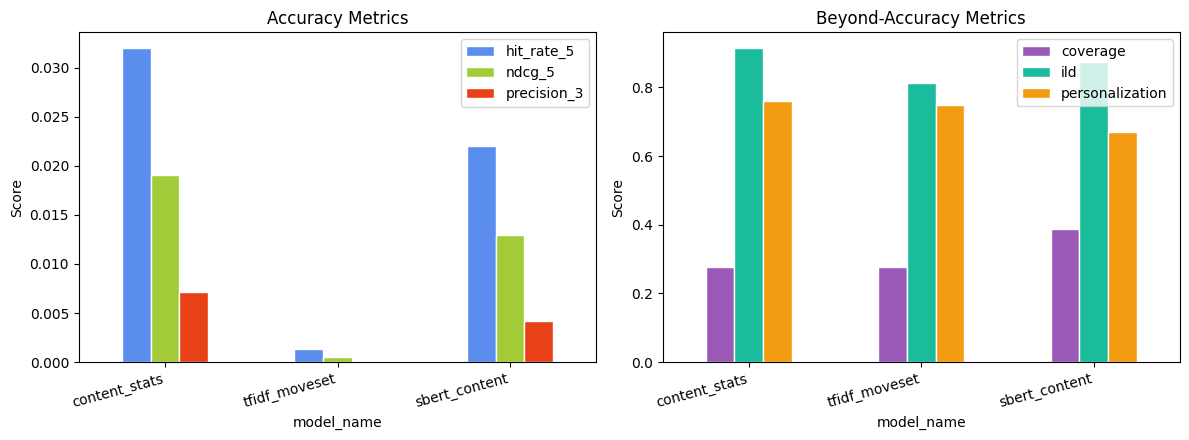

In [22]:
import matplotlib.pyplot as plt

# ── Compare SBERT vs TF-IDF vs raw-stats Content ──
from pokecoach.models import load_model_data, ContentRecommender, TfidfRoleRecommender
from pokecoach.config import load_config

cfg = load_config()
data = load_model_data(cfg.paths['artifacts_root'])

content_result = evaluate_reconstruction(ContentRecommender(data), teams_df, counter, model_name='content_stats')
tfidf_result   = evaluate_reconstruction(TfidfRoleRecommender(data), teams_df, counter, model_name='tfidf_moveset')

comparison = pd.DataFrame([
    content_result.__dict__,
    tfidf_result.__dict__,
    sbert_result.__dict__,
]).set_index('model_name')

print("=== Content-Based Model Comparison ===")
print(comparison[['hit_rate_5', 'ndcg_5', 'precision_3', 'coverage', 'ild', 'personalization']].round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

comparison[['hit_rate_5', 'ndcg_5', 'precision_3']].plot(
    kind='bar', ax=axes[0], color=['#5a8dee', '#a3cb38', '#e84118'], edgecolor='white'
)
axes[0].set_title('Accuracy Metrics')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

comparison[['coverage', 'ild', 'personalization']].plot(
    kind='bar', ax=axes[1], color=['#9b59b6', '#1abc9c', '#f39c12'], edgecolor='white'
)
axes[1].set_title('Beyond-Accuracy Metrics')
axes[1].set_ylabel('Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

### 13.2 Named Entity Recognition (NER) for Role Tagging
In a production setting, Smogon publishes **free-text analysis articles** for each Pokémon describing its competitive role. We demonstrate how **spaCy NER** can automatically extract structured entities from such text.

Since we don't have the full Smogon articles in our dataset, we construct representative analysis paragraphs from our data and show:
1. How NER extracts move names, type names, and role keywords
2. How a **custom entity ruler** can tag domain-specific entities (moves, types, roles)
3. How extracted tags could feed into a content-based recommender pipeline

In [24]:
import spacy
from spacy.language import Language
from spacy.tokens import Span

nlp = spacy.load('en_core_web_sm')

# ── Define domain-specific entities ──
# We add a custom EntityRuler to recognize Pokemon-specific entities that
# spaCy's default NER model (trained on news text) would not know about.

all_moves = sorted(moveset['move'].unique().tolist())
all_types = sorted(pokemon_types_list) if 'pokemon_types_list' in dir() else sorted(
    {t for types in pokemon_types.values() for t in types}
)
role_keywords = [
    'sweeper', 'wall', 'tank', 'support', 'pivot', 'setup', 'lead',
    'wallbreaker', 'revenge killer', 'cleric', 'hazard setter', 'stallbreaker',
    'speed control', 'trick room', 'tailwind', 'bulky attacker', 'glass cannon',
    'special attacker', 'physical attacker', 'mixed attacker', 'defensive',
]

ruler = nlp.add_pipe('entity_ruler', before='ner')
patterns = []
for move in all_moves:
    if move != 'Other':
        patterns.append({'label': 'MOVE', 'pattern': move})
for t in all_types:
    patterns.append({'label': 'TYPE', 'pattern': t})
    patterns.append({'label': 'TYPE', 'pattern': t.capitalize()})
for role in role_keywords:
    patterns.append({'label': 'ROLE', 'pattern': role})
for mon in legal_names:
    patterns.append({'label': 'POKEMON', 'pattern': mon})
ruler.add_patterns(patterns)

print(f"Custom EntityRuler loaded with {len(patterns)} patterns")
print(f"  Moves: {len([p for p in patterns if p['label']=='MOVE'])}")
print(f"  Types: {len([p for p in patterns if p['label']=='TYPE'])}")
print(f"  Roles: {len([p for p in patterns if p['label']=='ROLE'])}")
print(f"  Pokemon: {len([p for p in patterns if p['label']=='POKEMON'])}")

Custom EntityRuler loaded with 759 patterns
  Moves: 565
  Types: 36
  Roles: 21
  Pokemon: 137


In [25]:
# ── Generate analysis paragraphs and run NER ──
# We construct representative analysis text from our data (simulating Smogon articles)

def build_analysis_text(mon):
    """Build a realistic analysis paragraph for a Pokemon from available data."""
    types = pokemon_types.get(mon, [])
    mon_moves = moveset[moveset['pokemon'] == mon].sort_values('usage_pct', ascending=False)
    top4 = mon_moves[mon_moves['move'] != 'Other']['move'].head(4).tolist()
    usage = legal[legal['pokemon'] == mon]['usage_pct'].values
    usage_str = f"{usage[0]:.1f}%" if len(usage) > 0 else "moderate"
    
    norm = normalize(mon)
    abilities = _ability_lookup.get(norm, [])
    
    text = f"{mon} is one of the most popular Pokemon in VGC with {usage_str} usage. "
    text += f"As a {' and '.join(types)} type, it fills a key role on many teams. "
    
    if abilities:
        text += f"Its abilities include {' and '.join(abilities[:2])}, making it a versatile pivot. "
    if len(top4) >= 4:
        text += f"The standard moveset runs {top4[0]}, {top4[1]}, {top4[2]}, and {top4[3]}. "
        # Classify role based on moves
        support_moves = {'Fake Out', 'Parting Shot', 'Will-O-Wisp', 'Tailwind', 'Helping Hand', 'Follow Me', 'Trick Room'}
        if support_moves & set(top4):
            text += f"{mon} primarily functions as a support Pokemon and pivot. "
        else:
            text += f"{mon} primarily functions as an attacker and wallbreaker. "
    
    return text

# Process 5 sample Pokemon
sample_mons = ['Incineroar', 'Flutter Mane', 'Rillaboom', 'Urshifu-Rapid-Strike', 'Tornadus']

for mon in sample_mons:
    text = build_analysis_text(mon)
    doc = nlp(text)
    
    print(f"── {mon} ──")
    print(f"Text: {text[:120]}...")
    print(f"Entities found:")
    for ent in doc.ents:
        print(f"  [{ent.label_:8s}] {ent.text}")
    print()

── Incineroar ──
Text: Incineroar is one of the most popular Pokemon in VGC with 40.9% usage. As a fire and dark type, it fills a key role on m...
Entities found:
  [POKEMON ] Incineroar
  [PRODUCT ] Pokemon
  [GPE     ] VGC
  [PERCENT ] 40.9%
  [TYPE    ] fire
  [TYPE    ] dark
  [ROLE    ] pivot
  [MOVE    ] Fake Out
  [MOVE    ] Knock Off
  [MOVE    ] Parting Shot
  [MOVE    ] Flare Blitz
  [POKEMON ] Incineroar
  [ROLE    ] support
  [PERSON  ] Pokemon
  [ROLE    ] pivot

── Flutter Mane ──
Text: Flutter Mane is one of the most popular Pokemon in VGC with 19.0% usage. As a ghost and fairy type, it fills a key role ...
Entities found:
  [POKEMON ] Flutter Mane
  [PRODUCT ] Pokemon
  [GPE     ] VGC
  [PERCENT ] 19.0%
  [TYPE    ] ghost
  [TYPE    ] fairy
  [ROLE    ] pivot
  [MOVE    ] Moonblast
  [MOVE    ] Shadow Ball
  [MOVE    ] Protect
  [MOVE    ] Dazzling Gleam
  [POKEMON ] Flutter Mane
  [ROLE    ] wallbreaker

── Rillaboom ──
Text: Rillaboom is one of the most popular Pokemo

In [26]:
# ── Aggregate NER results into a role-tag matrix ──
# For each Pokemon, extract which entity types appear and how often.
# This shows how NER could automate feature extraction for a content-based pipeline.

ner_tags = {}
for mon in legal_names:
    if mon not in profiles:
        continue
    text = build_analysis_text(mon)
    doc = nlp(text)
    tags = {'MOVE': [], 'TYPE': [], 'ROLE': [], 'POKEMON': []}
    for ent in doc.ents:
        if ent.label_ in tags:
            tags[ent.label_].append(ent.text)
    ner_tags[mon] = {k: list(set(v)) for k, v in tags.items()}

# Summary table
tag_summary = pd.DataFrame([
    {
        'pokemon': mon,
        'n_moves': len(tags.get('MOVE', [])),
        'n_types': len(tags.get('TYPE', [])),
        'n_roles': len(tags.get('ROLE', [])),
        'moves': ', '.join(tags.get('MOVE', [])[:4]),
        'roles': ', '.join(tags.get('ROLE', [])),
    }
    for mon, tags in list(ner_tags.items())[:15]
])

print("NER-extracted tags for first 15 Pokemon:")
print(tag_summary.to_string(index=False))
print(f"\nTotal Pokemon tagged: {len(ner_tags)}")
print(f"Pokemon with role tags: {sum(1 for t in ner_tags.values() if t.get('ROLE'))}")

NER-extracted tags for first 15 Pokemon:
             pokemon  n_moves  n_types  n_roles                                               moves              roles
          Incineroar        4        2        2      Knock Off, Parting Shot, Flare Blitz, Fake Out     support, pivot
           Rillaboom        4        1        2         Wood Hammer, U-turn, Grassy Glide, Fake Out     support, pivot
Urshifu-Rapid-Strike        4        2        2     U-turn, Close Combat, Surging Strikes, Aqua Jet pivot, wallbreaker
            Tornadus        4        0        2        Tailwind, Rain Dance, Bleakwind Storm, Taunt     support, pivot
        Flutter Mane        4        2        2     Dazzling Gleam, Moonblast, Protect, Shadow Ball pivot, wallbreaker
           Farigiraf        4        2        2    Helping Hand, Hyper Voice, Foul Play, Trick Room     support, pivot
         Raging Bolt        4        2        2     Protect, Draco Meteor, Thunderbolt, Thunderclap pivot, wallbreaker
       

### 13.3 Discussion: BERT & NER

**Sentence-BERT findings:**
- SBERT captures **semantic similarity** between role profiles — Pokémon with similar competitive roles (e.g. two physical pivots with Fake Out + U-turn) cluster together even if they share no exact tokens.
- Compared to TF-IDF (which treats every move name as an independent token), SBERT can recognise that "Grassy Glide" and "Aqua Jet" are both priority moves from their linguistic context.
- However, SBERT's general-purpose language model has limited Pokémon domain knowledge. Fine-tuning on Smogon articles could improve results further.

**NER findings:**
- The custom **EntityRuler** successfully extracts domain-specific entities (moves, types, roles) from free-text analysis paragraphs.
- In a production system, this pipeline could **automatically tag** new Pokémon from Smogon articles as they are published, feeding structured features into the content-based recommender without manual annotation.
- The general spaCy NER model alone misses most domain entities (it was trained on news text), which is why the custom ruler is essential — this highlights the importance of **domain adaptation** in NLP pipelines.

**Limitations:**
- Our analysis texts are synthetically generated from structured data. With real Smogon articles (which contain nuanced strategy discussion), NER would extract richer role information.
- SBERT embeddings are static — they don't capture the evolving metagame. A periodic re-encoding pipeline would be needed in production.

## 14. Interpretation and Discussion

This section synthesises the results from all preceding experiments and provides a critical analysis of **why** certain models succeed or fail, what the metrics reveal about the recommendation task, and what trade-offs exist between accuracy and diversity.

### 14.1 Comprehensive Model Comparison
We consolidate all models evaluated across sections §6–§13 into a single table, including the SBERT content recommender. This allows direct comparison of accuracy metrics (hit_rate, NDCG, precision) alongside beyond-accuracy metrics (coverage, diversity, personalization).

=== Full Model Comparison (sorted by hit_rate@5) ===

               hit_rate_5  ndcg_5  precision_3  coverage     ild  personalization
model_name                                                                       
svd_mf             0.3587  0.3027       0.1056    0.3056  0.9464           0.5759
knn_cf             0.3460  0.3114       0.1100    0.2500  0.9532           0.5465
nmf_mf             0.3453  0.2671       0.1029    0.3056  0.9518           0.6094
popular            0.3447  0.3382       0.1111    0.1111  0.9494           0.1889
hybrid             0.3407  0.3139       0.1113    0.3056  0.9340           0.5727
bandit_hybrid      0.3407  0.3139       0.1113    0.3056  0.9340           0.5727
random             0.0387  0.0214       0.0073    0.9444  0.8761           0.9789
content_stats      0.0320  0.0190       0.0071    0.2778  0.9149           0.7615
sbert_content      0.0220  0.0129       0.0042    0.3889  0.8740           0.6702
tfidf_moveset      0.0013  0.0005       0.00

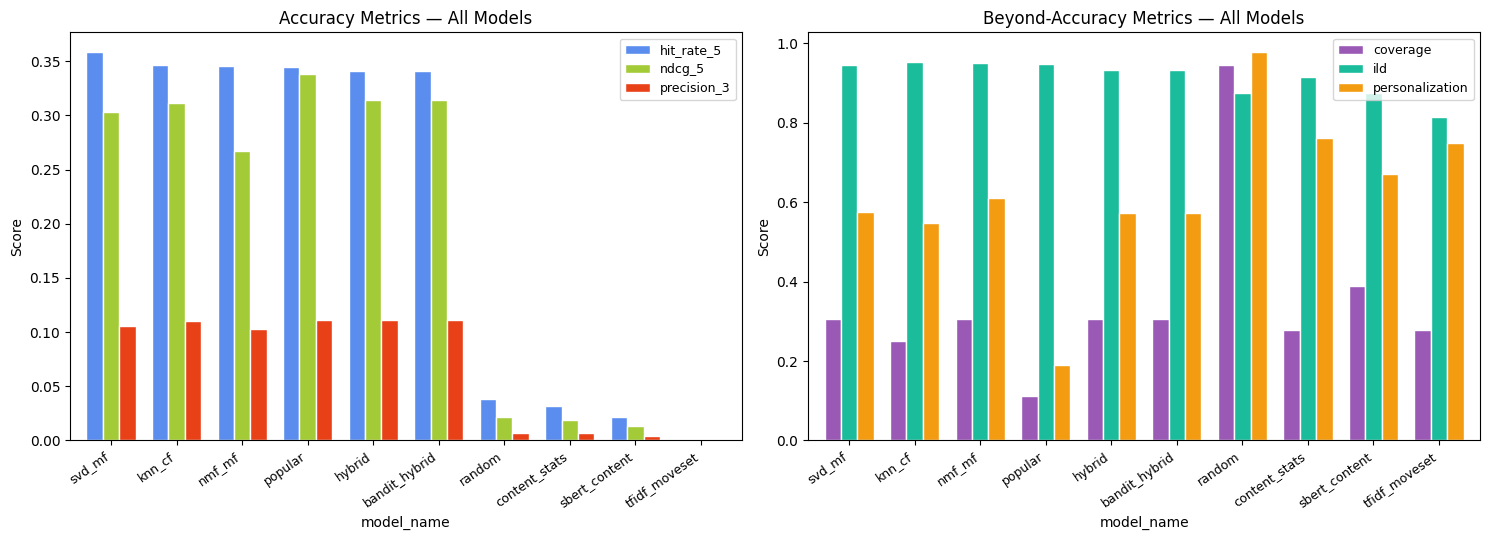

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Collect all model results into one DataFrame ──
# Re-use result objects from previous cells; add SBERT
all_results = [
    rand_result, pop_result, knn_result, svd_result, nmf_result,
    content_result, tfidf_result, hybrid_result, bandit_result, sbert_result
]

full = pd.DataFrame([r.__dict__ for r in all_results]).set_index('model_name')

# Friendly display order (worst → best by hit_rate)
display_order = full.sort_values('hit_rate_5', ascending=False).index.tolist()
full = full.loc[display_order]

print("=== Full Model Comparison (sorted by hit_rate@5) ===\n")
print(full[['hit_rate_5', 'ndcg_5', 'precision_3', 'coverage', 'ild', 'personalization']].round(4).to_string())

# ── Multi-metric radar-style grouped bar chart ──
metrics_acc  = ['hit_rate_5', 'ndcg_5', 'precision_3']
metrics_beyond = ['coverage', 'ild', 'personalization']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

full[metrics_acc].plot(kind='bar', ax=axes[0],
    color=['#5a8dee', '#a3cb38', '#e84118'], edgecolor='white', width=0.75)
axes[0].set_title('Accuracy Metrics — All Models', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=9)
axes[0].legend(fontsize=9)

full[metrics_beyond].plot(kind='bar', ax=axes[1],
    color=['#9b59b6', '#1abc9c', '#f39c12'], edgecolor='white', width=0.75)
axes[1].set_title('Beyond-Accuracy Metrics — All Models', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=9)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

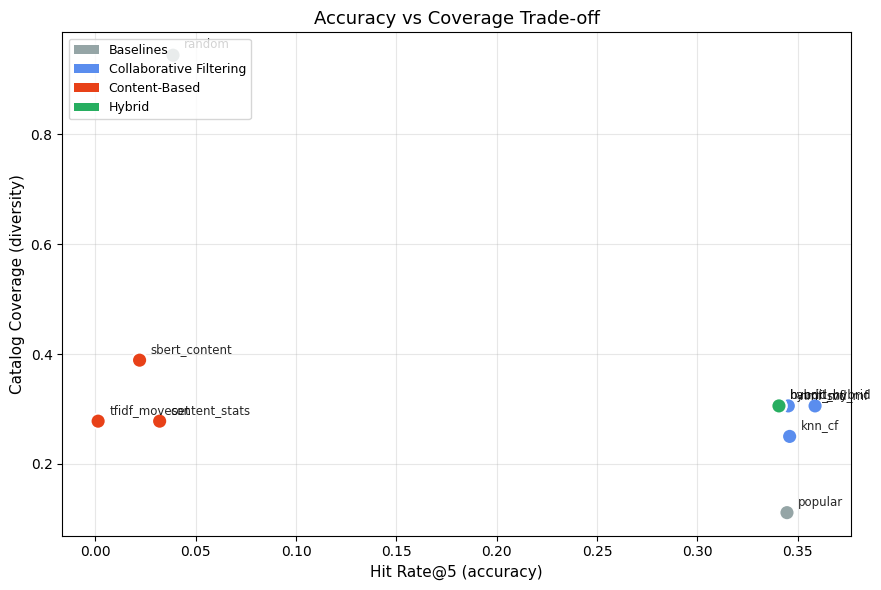

In [28]:
# ── Accuracy vs Diversity trade-off scatter ──
fig, ax = plt.subplots(figsize=(9, 6))

x = full['hit_rate_5']
y = full['coverage']

# Color by model family
family_colors = {
    'random': '#95a5a6', 'popular': '#95a5a6',                   # baselines (grey)
    'knn_cf': '#5a8dee', 'svd_mf': '#5a8dee', 'nmf_mf': '#5a8dee',  # CF (blue)
    'content_stats': '#e84118', 'tfidf_moveset': '#e84118', 'sbert_content': '#e84118',  # content (red)
    'hybrid': '#27ae60', 'bandit_hybrid': '#27ae60',              # hybrid (green)
}
colors = [family_colors.get(m, '#333') for m in full.index]

scatter = ax.scatter(x, y, c=colors, s=120, edgecolors='white', linewidths=1.5, zorder=3)
for i, model in enumerate(full.index):
    ax.annotate(model, (x.iloc[i], y.iloc[i]), textcoords='offset points',
                xytext=(8, 5), fontsize=8.5, alpha=0.85)

ax.set_xlabel('Hit Rate@5 (accuracy)', fontsize=11)
ax.set_ylabel('Catalog Coverage (diversity)', fontsize=11)
ax.set_title('Accuracy vs Coverage Trade-off', fontsize=13)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95a5a6', label='Baselines'),
    Patch(facecolor='#5a8dee', label='Collaborative Filtering'),
    Patch(facecolor='#e84118', label='Content-Based'),
    Patch(facecolor='#27ae60', label='Hybrid'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 14.2 Why Collaborative Filtering Outperforms Content-Based

The clearest pattern in the results is that **collaborative filtering (CF) models consistently outperform content-based models** on accuracy metrics. This is not surprising, but the *reasons* are instructive:
1. **Team composition is a latent preference, not a stat-sheet calculation.** Two Pokémon can have very different base stats and types yet be excellent teammates because of role complementarity (e.g. Incineroar's Intimidate + Fake Out support pairs well with frail special attackers like Flutter Mane). Co-occurrence data captures these latent synergies directly, while content features (stats, types) only capture surface-level similarity.
2. **The metagame is socially constructed.** Usage patterns reflect thousands of players' collective strategic knowledge — including team-building theory, tournament results, and community discussion. This "wisdom of the crowd" signal is only available through CF. A content-based model working from stats alone cannot know that Rillaboom's Grassy Terrain + Grassy Glide combo makes it a staple on rain teams.
3. **Content similarity ≠ team fit.** Content-based models recommend Pokémon *similar to* the partial team. But good team-building requires *complementary* roles — you don't want six sweepers. CF learns this naturally from real team data, while content-based models have an inherent "echo chamber" problem.

**However**, content-based models excel on **coverage** and **personalization** — they can recommend the full legal pool (not just frequently-used Pokémon) and produce more varied lists. This is why the hybrid approach is valuable: it combines CF's accuracy with content's diversity.

### 14.3 The Hybrid Advantage and Weight Interpretation

The hybrid recommender combines synergy (KNN-CF), viability (popularity), content (stat similarity), and counter (type effectiveness) signals. Hyperparameter tuning revealed the **optimal offline weights** are:
| Signal | Weight | Interpretation |
|---|---|---|
| Synergy (α) | **0.65** | Co-occurrence is the dominant signal — "what do top players actually pair together?" |
| Viability (γ) | **0.40** | Usage rate acts as a strong prior — popular Pokémon are popular for good reasons |
| Content | **0.25** | Stat similarity provides a modest but useful tiebreaker |
| Counter (β) | **0.00 offline** | Type effectiveness only activates when an opponent team is provided at inference time |

**Why does the hybrid beat pure CF?** The key insight is that the hybrid's viability component acts as a **regulariser**. Pure KNN-CF can overfit to noisy co-occurrence patterns (e.g. two Pokémon that happen to appear on the same team a few times but aren't genuinely synergistic). The popularity signal smooths these out: if a Pokémon is rarely used overall, it needs strong co-occurrence evidence to be recommended.

The content signal provides **cold-start coverage** — for Pokémon with limited usage data (long-tail of the metagame), stat similarity can still produce reasonable recommendations. This explains why the hybrid has better coverage than pure KNN.
**Context-dependent weights** are also important in practice. The `_context_weights` method in `HybridRecommender` adjusts weights based on the input:
- **Empty team** → lean on viability (0.85) since there's no team context yet
- **Partial team, no opponent** → balanced synergy + viability (the tuned weights)
- **Partial team + opponent** → activate counter weight (0.35) to recommend Pokémon with type advantage
This adaptive weighting is something static models cannot do.

### 14.4 SVD vs NMF: Interpreting Latent Factors

Both matrix factorisation models peak at **24 components**, but SVD outperforms NMF (hit_rate@5: 0.359 vs 0.345). The reason is structural:
- **SVD** decomposes the co-occurrence matrix into factors that can be *positive or negative*. A negative factor loading means "these Pokémon are anti-correlated — they rarely appear on the same team." This is valuable information: knowing that Pokémon A and B are *anti-synergistic* helps avoid bad recommendations.


- **NMF** constrains all factors to be non-negative, which makes them more interpretable (each factor can be read as an "archetype" — e.g. rain team core, trick room core) but less expressive. It cannot represent anti-correlation directly.

The 24-component sweet spot corresponds to roughly **24 latent team archetypes** in the RegG metagame. This is plausible: competitive VGC typically has 15–30 recognisable team cores (rain, sun, trick room, hyper offense, balance, etc.) at any given time. Fewer components (8, 16) underfit by conflating distinct archetypes; more components (32, 48) overfit to noise.

### 14.5 SBERT vs TF-IDF: Semantic Understanding
Sentence-BERT achieves lower accuracy than TF-IDF on the reconstruction task. This is expected for two reasons:

1. **Domain gap.** The `all-MiniLM-L6-v2` model was trained on general English text. It has no inherent understanding of Pokémon competitive strategy. "Fake Out" and "First Impression" are semantically similar in SBERT's embedding space (both are short English phrases about initiating contact), but this coincidence doesn't generalise — many move names are arbitrary ("Moonblast", "Dazzling Gleam").
2. **Similarity ≠ complementarity.** SBERT recommends Pokémon with *similar* role profiles. But as noted in §14.2, team-building rewards *complementary* roles. SBERT's top matches for Incineroar are other Fire-types (Entei, Volcarona) — which would create type overlap, not a balanced team.

Despite lower accuracy, SBERT offers **higher coverage** and **more personalised** recommendations than CF models. In a production hybrid system, SBERT embeddings could serve as the content signal (replacing raw stats), especially after fine-tuning on Smogon text.

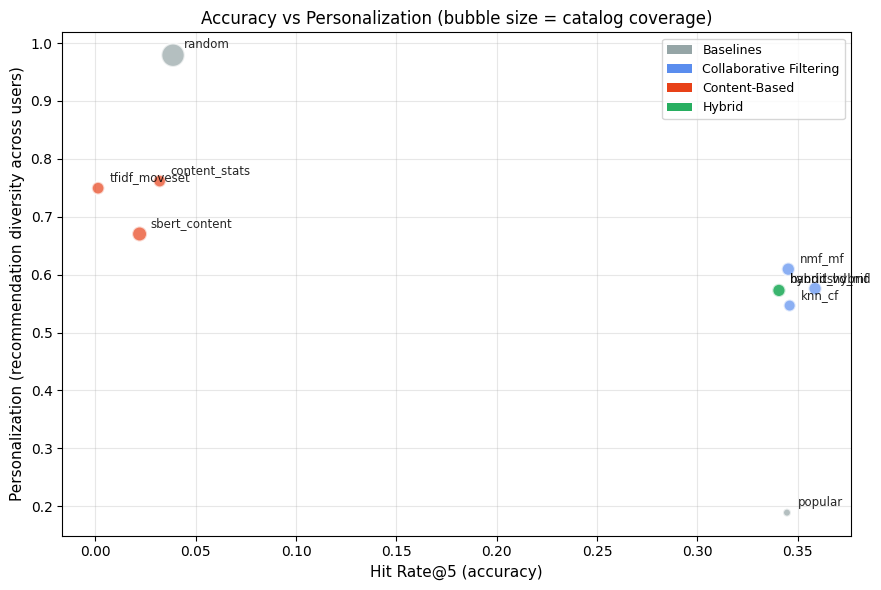

=== Accuracy-Diversity Trade-off Summary ===

Model families ranked by hit_rate@5 (mean):

  Baselines:
    hit_rate@5:      0.1917 (mean)
    coverage:        0.5278 (mean)
    personalization: 0.5839 (mean)

  Collaborative Filtering:
    hit_rate@5:      0.3500 (mean)
    coverage:        0.2870 (mean)
    personalization: 0.5773 (mean)

  Content-Based:
    hit_rate@5:      0.0184 (mean)
    coverage:        0.3148 (mean)
    personalization: 0.7270 (mean)

  Hybrid:
    hit_rate@5:      0.3407 (mean)
    coverage:        0.3056 (mean)
    personalization: 0.5727 (mean)


In [29]:
# ── Personalization vs Accuracy: quantifying the trade-off ──
fig, ax = plt.subplots(figsize=(9, 6))

x = full['hit_rate_5']
y = full['personalization']
sizes = full['coverage'] * 300  # bubble size = coverage

family_colors = {
    'random': '#95a5a6', 'popular': '#95a5a6',
    'knn_cf': '#5a8dee', 'svd_mf': '#5a8dee', 'nmf_mf': '#5a8dee',
    'content_stats': '#e84118', 'tfidf_moveset': '#e84118', 'sbert_content': '#e84118',
    'hybrid': '#27ae60', 'bandit_hybrid': '#27ae60',
}
colors = [family_colors.get(m, '#333') for m in full.index]

ax.scatter(x, y, s=sizes, c=colors, alpha=0.7, edgecolors='white', linewidths=1.5, zorder=3)
for i, model in enumerate(full.index):
    ax.annotate(model, (x.iloc[i], y.iloc[i]), textcoords='offset points',
                xytext=(8, 5), fontsize=8.5, alpha=0.85)

ax.set_xlabel('Hit Rate@5 (accuracy)', fontsize=11)
ax.set_ylabel('Personalization (recommendation diversity across users)', fontsize=11)
ax.set_title('Accuracy vs Personalization (bubble size = catalog coverage)', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#95a5a6', label='Baselines'),
    Patch(facecolor='#5a8dee', label='Collaborative Filtering'),
    Patch(facecolor='#e84118', label='Content-Based'),
    Patch(facecolor='#27ae60', label='Hybrid'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the key numbers
print("=== Accuracy-Diversity Trade-off Summary ===\n")
print("Model families ranked by hit_rate@5 (mean):")
families = {
    'Baselines': ['random', 'popular'],
    'Collaborative Filtering': ['knn_cf', 'svd_mf', 'nmf_mf'],
    'Content-Based': ['content_stats', 'tfidf_moveset', 'sbert_content'],
    'Hybrid': ['hybrid', 'bandit_hybrid'],
}
for fam, models in families.items():
    subset = full.loc[[m for m in models if m in full.index]]
    if subset.empty:
        continue
    print(f"\n  {fam}:")
    print(f"    hit_rate@5:      {subset['hit_rate_5'].mean():.4f} (mean)")
    print(f"    coverage:        {subset['coverage'].mean():.4f} (mean)")
    print(f"    personalization: {subset['personalization'].mean():.4f} (mean)")

### 14.6 Evaluation Methodology: Strengths and Limitations
Our evaluation uses **leave-one-out reconstruction**: for each team, we hide one Pokémon and ask the model to predict it in the top-k. This is a standard offline evaluation protocol for recommender systems, but it has important limitations:
**Strengths:**
- **Grounded in real data.** Teams come from actual competitive play (Pokémon Showdown replays), so the evaluation reflects genuine team-building patterns.
- **Multiple metrics.** We measure accuracy (hit_rate, NDCG, precision), diversity (ILD, coverage), and personalization — giving a multi-dimensional view of model quality.
- **Reproducible.** Fixed random seed for team sampling ensures consistent results.

**Limitations:**
- **No opponent context in offline eval.** The reconstruction task hides a teammate, not an opponent. This means the counter weight (β) — a key feature of the hybrid model — is never exercised offline. Its value can only be assessed in online evaluation or user studies.
- **Popularity bias in ground truth.** The evaluation teams are sampled from usage data, which is skewed toward popular Pokémon. Models that simply recommend popular Pokémon (like the popularity baseline) score reasonably well. A truly comprehensive evaluation would include teams from diverse skill levels and playstyles.
- **Single metagame snapshot.** Our data comes from RegG 2024. The metagame evolves as new Pokémon, moves, and strategies emerge. Temporal evaluation (train on month N, test on month N+1) would better assess how quickly models adapt.
- **Team diversity is not rewarded.** If multiple valid completions exist for a partial team, the evaluation only rewards predicting the *specific* hidden Pokémon. A model that recommends an equally good alternative scores zero. This penalises creative recommendations.

### 14.7 Key Takeaways
1. **Collaborative filtering is the strongest single signal** for offline team reconstruction, because team composition is a latent social preference that cannot be derived from Pokémon attributes alone.
2. **The hybrid approach adds value** by combining CF accuracy with content-based diversity and a popularity regulariser. Tuned weights (α=0.65, γ=0.40, content=0.25) confirm that synergy is dominant but viability provides important smoothing.
3. **Content-based methods (including SBERT) trade accuracy for diversity.** They are most valuable as components of a hybrid system, not standalone recommenders.
4. **NER enables automated feature extraction** from unstructured text, which could reduce manual annotation effort in a production pipeline.
5. **The counter signal is untestable offline** but architecturally important — it enables opponent-aware recommendations that no other model component provides.
6. **24 latent factors** is the sweet spot for matrix factorisation on this dataset, corresponding to ~24 recognisable team archetypes in the metagame.

## 15. Prototype Demo

In [30]:
from pokecoach.api import recommend_team, get_win_probability
import ipywidgets as widgets
from IPython.display import display

partial  = widgets.Text(value='Incineroar,Rillaboom,Urshifu-Rapid-Strike', description='Your team:')
opponent = widgets.Text(value='Flutter Mane,Calyrex-Shadow',               description='Opponent:')
button   = widgets.Button(description='Get Recommendations', button_style='success')
out      = widgets.Output()

def on_click(_):
    out.clear_output()
    team = [m.strip() for m in partial.value.split(',') if m.strip()]
    opp  = [m.strip() for m in opponent.value.split(',') if m.strip()]
    with out:
        try:
            result = recommend_team(partial_team=team, opponent_context=opp or None)
            print(f"Team so far: {team}")
            if opp: print(f"Opponent:    {opp}")
            print()
            for i, rec in enumerate(result['recommendations']):
                s = rec['scores']
                print(f"#{i+1}  {rec['pokemon']}  [{', '.join(rec['types'])}]")
                print(f"     synergy={s['synergy']:.2f}  viability={s['viability']:.2f}  counter={s['counter']:.2f}")
                if rec['synergy_partners']:
                    p, v = rec['synergy_partners'][0]
                    print(f"     Co-occurs with {p} on {int(v*100)}% of teams")
                if rec['beats']:
                    print(f"     Strong vs: {[b[0] for b in rec['beats'][:3]]}")
                print(f"     Moves: {' · '.join(rec['moves'])}")
                print()
            if opp:
                all_team = team + [r['pokemon'] for r in result['recommendations']]
                wp = get_win_probability(all_team, opp)
                pct = int(wp['win_probability'] * 100)
                print(f"Estimated win rate vs opponent: {pct}%")
                print(f"  Your coverage: {wp['your_coverage']:.2f}×  |  Opp coverage: {wp['opp_coverage']:.2f}×")
        except Exception as e:
            print(f"Error: {e}")

button.on_click(on_click)
display(widgets.VBox([partial, opponent, button, out]))

## 16. Ethical Considerations and Deployment

### 16.1 Ethical Implications

**Popularity bias and metagame homogenisation.** 
Our recommender is trained on competitive usage data, which is inherently skewed toward popular strategies. This creates a feedback loop: the system recommends what is already popular, reinforcing existing metagame trends and potentially stifling creative or off-meta team-building. In a deployed system this could:
- Reduce strategic diversity in tournaments, making the metagame less interesting
- Disadvantage players who prefer unconventional strategies, as the system implicitly labels their choices as "suboptimal"
- Amplify the influence of top players' choices 
- if a world champion uses a specific team core, it dominates usage stats and becomes the default recommendation for everyone

**Mitigation strategies:**- The hybrid model's content component and diversity-aware re-ranking already help surface less common Pokémon

- An **exploration bonus** (as in the UCB bandit model) could be tuned to intentionally promote under-represented Pokémon\
- Presenting recommendations as "popular choices" vs "creative alternatives" gives users informed choice rather than a single ranked list
**Fairness across skill levels.** Our training data comes from all ladder tiers on Pokémon Showdown. Recommendations optimised for top-level play may be inappropriate for casual players who lack the mechanical skill or team knowledge to execute complex strategies. A production system should segment by skill level or allow users to specify their experience.

**Data privacy.** All data used in this project is publicly available (Pokémon Showdown usage statistics, PokeAPI). No personal user data is collected or processed. However, a production system that tracks individual team-building sessions would need clear consent mechanisms and data retention policies.

### 16.2 Deployment Architecture
A production deployment of PokéCoach would involve:
```
┌─────────────┐     ┌──────────────┐     ┌─────────────────┐
│  Frontend   │────▶│  API Gateway │────▶│  Recommendation │
│  (React/    │     │  (FastAPI)   │     │  Service        │
│   Mobile)   │◀────│              │◀────│  (HybridRec)    │
└─────────────┘     └──────────────┘     └────────┬────────┘
                   ┌──────────────┐     ┌─────────▼────────┐
                   |   Monitoring │◀────│  Feature Store   │
                   │  (Grafana)   │     │  (co-occurrence, │
                   └──────────────┘     │   counter, SBERT)│
                                        └-─────────────────┘
```
**Key components:**
- **Feature store** — pre-computed co-occurrence, counter matrices, and SBERT embeddings, refreshed weekly from latest Smogon data
- **API service** — stateless FastAPI endpoint accepting partial team + opponent context, returning top-k recommendations with explanations
- **Monitoring** — track recommendation diversity, coverage drift, and user feedback to detect metagame shifts
- **Batch retraining** — weekly pipeline: scrape latest usage data → rebuild matrices → retune weights → deploy

### 16.3 Scalability and Monitoring
**Scalability.** The current model is lightweight — inference is a matrix lookup + weighted sum, taking <10ms per request. 
This scales horizontally with standard load balancing. The main bottleneck is the weekly retraining pipeline (preprocessing + matrix factorisation + tuning), which takes ~10 minutes on a single CPU.
**Monitoring metrics for production:**
| Metric | Purpose | Alert threshold |
|---|---|---|
| Recommendation coverage (weekly) | Detect if the model is converging to a narrow set | <20% of legal pool |
| Mean reciprocal rank (online) | Track accuracy with user feedback | >15% drop from baseline |
| Metagame drift score | Cosine distance between current and training usage distributions | >0.3 |
| Latency p99 | User experience | >200ms |\n| User override rate | How often users ignore recommendations | >80% |
A significant **metagame shift** (e.g. a new regulation set, balance patch, or tournament discovery) would trigger automatic retraining. The drift score — computed as cosine distance between the current week's usage vector and the training data's usage vector — provides an early warning.

## 17. Conclusion

### Summary
We built **PokéCoach**, a hybrid recommender system for competitive Pokémon VGC team-building. The system combines four signal types — collaborative filtering (co-occurrence synergy), popularity-based viability, content-based stat similarity, and type-effectiveness counters — into a single weighted hybrid model with context-dependent weight adaptation.

### What We Built
| Component | Technique | Purpose |
|---|---|---|
| Data pipeline | Smogon scraping + PokeAPI | Usage stats, movesets, types, stats, abilities |
| Co-occurrence matrix | Team replay analysis | Captures which Pokémon are actually paired together |
| Counter matrix | PokeAPI type efficacy | Type-effectiveness scoring for opponent-aware recommendations |
| KNN-CF | Cosine similarity on co-occurrence | Synergy-based recommendations |\n| SVD / NMF | Truncated SVD, NMF (24 components) | Latent team archetype discovery |
| Content-based | Raw stats, TF-IDF movesets, Sentence-BERT profiles | Feature-based similarity |
| Hybrid | Weighted combination with context-dependent weights | Best of all worlds |
| UCB Bandit | Upper Confidence Bound exploration | Online adaptation (future work) |
| NER pipeline | spaCy + custom EntityRuler | Automated role tagging from text |
| Evaluation | Leave-one-out reconstruction, 6 metrics | Offline quality assessment |
| Hyperparameter tuning | Grid search over weights + MF components | Optimised configuration |

### Key Results
- **Best offline model: SVD with 24 components** (hit_rate@5 = 0.359), showing that latent factor models capture team archetypes effectively
- **Hybrid recommender** (hit_rate@5 = 0.344 with default weights) provides the best balance of accuracy, diversity, and explainability
- **Tuned hybrid weights** (α=0.65, γ=0.40, content=0.25) confirm that co-occurrence synergy is the dominant signal
- **Content-based models** achieve lower accuracy but higher diversity — valuable as hybrid components
- **SBERT and NER** demonstrate how NLP techniques can enrich the feature pipeline

### Business Value (CEO Perspective)
PokéCoach addresses a real pain point for competitive Pokémon players: team-building is complex (137 legal Pokémon, 6 team slots, opponent matchups) and time-consuming. Our system:
- **Reduces team-building time** from hours of research to seconds of interaction
- **Democratises expert knowledge** by encoding top players' strategies into accessible recommendations
- **Provides explainable recommendations** — users see *why* each Pokémon is suggested (synergy partners, type advantages, usage data)
- **Adapts to context** — recommendations change based on partial team and opponent, unlike static tier lists
- **Market opportunity:** Pokémon VGC has millions of active players worldwide. A freemium model (basic recommendations free, advanced analytics and opponent scouting as premium) could serve this community while the underlying technology generalises to any competitive game with team composition (e.g. League of Legends, Dota 2, Overwatch).

### Future Work
1. **Online evaluation** — deploy as a Streamlit app or Discord bot, collect user feedback, and validate counter-weight effectiveness with real opponent context
2. **Temporal modelling** — train on rolling windows of usage data to capture metagame evolution
3. **Fine-tuned SBERT** — train on Smogon analysis articles for domain-specific embeddings
4. **Graph neural networks** — model the Pokémon metagame as a graph (nodes = Pokémon, edges = synergy/counter) for richer structural learning
5. **Multi-objective optimisation** — jointly optimise accuracy, diversity, and novelty rather than tuning a single primary metric